<a href="https://colab.research.google.com/github/Fzzrr/retail-forecasting-application/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [2]:
import kagglehub

path = kagglehub.dataset_download("anirudhchauhan/retail-store-inventory-forecasting-dataset")

print('Path to dataset:', path)

Using Colab cache for faster access to the 'retail-store-inventory-forecasting-dataset' dataset.
Path to dataset: /kaggle/input/retail-store-inventory-forecasting-dataset


In [3]:
import os

files = os.listdir(path)
print('Files in dataset:', files)

Files in dataset: ['retail_store_inventory.csv']


In [4]:
file_name = files[0]
full_path = os.path.join(path, file_name)

df = pd.read_csv(full_path)
print('Dataset loaded successfully!')
print('First 5 rows of the dataset:')
df.head(5)

Dataset loaded successfully!
First 5 rows of the dataset:


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                73100 non-null  object 
 1   Store ID            73100 non-null  object 
 2   Product ID          73100 non-null  object 
 3   Category            73100 non-null  object 
 4   Region              73100 non-null  object 
 5   Inventory Level     73100 non-null  int64  
 6   Units Sold          73100 non-null  int64  
 7   Units Ordered       73100 non-null  int64  
 8   Demand Forecast     73100 non-null  float64
 9   Price               73100 non-null  float64
 10  Discount            73100 non-null  int64  
 11  Weather Condition   73100 non-null  object 
 12  Holiday/Promotion   73100 non-null  int64  
 13  Competitor Pricing  73100 non-null  float64
 14  Seasonality         73100 non-null  object 
dtypes: float64(3), int64(5), object(7)
memory usage: 8.4+

In [6]:
df.drop(columns=['Store ID', 'Product ID', 'Region', 'Demand Forecast'], inplace=True)
df.head(5)

,Date,Category,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,Groceries,231,127,55,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,Toys,204,150,66,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,Toys,102,65,51,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,Toys,469,61,164,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,Electronics,166,14,135,73.64,0,Sunny,0,68.95,Summer


In [7]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
cols = ['Category', 'Weather Condition', 'Seasonality']
for col in cols:
    df[col] = le.fit_transform(df[col])
df.head(5)

,Date,Category,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,3,231,127,55,33.50,20,1,0,29.69,0
1,2022-01-01,4,204,150,66,63.01,20,3,0,66.16,0
2,2022-01-01,4,102,65,51,27.99,10,3,1,31.32,2
3,2022-01-01,4,469,61,164,32.72,10,0,1,34.74,0
4,2022-01-01,1,166,14,135,73.64,0,3,0,68.95,2


In [8]:
# 3. Agregasi: Kelompokkan berdasarkan 'Date' dan 'Category'
# Di sini kita tentukan kolom mana yang ingin di-SUM dan mana yang di-MEAN

df['Date'] = pd.to_datetime(df['Date'])  # Pastikan kolom 'Date' dalam format datetime

df_hasil = df.groupby(['Date', 'Category']).agg({
    'Units Sold': 'sum',          # Total penjualan harian per kategori
    'Inventory Level': 'sum',    # Rata-rata stok harian
    'Units Ordered': 'sum',       # Total pesanan stok baru
    'Price': 'sum',              # Rata-rata harga di kategori tersebut
    # 'Demand Forecast': 'mean',    # Rata-rata prediksi permintaan
    'Holiday/Promotion': 'mean',   # 1 jika ada promo, 0 jika tidak (mengambil nilai tertinggi)
    'Seasonality': 'mean'         # Rata-rata nilai seasonality
}).reset_index()                  # WAJIB: Agar 'Date' dan 'Category' kembali jadi kolom

df_hasil[['Holiday/Promotion', 'Seasonality']] = df_hasil[['Holiday/Promotion', 'Seasonality']].round(0).astype(int)

# 4. Menampilkan Hasil
print("Hasil Kalkulasi Per Hari Berdasarkan Kategori:")
df_hasil.head()

Hasil Kalkulasi Per Hari Berdasarkan Kategori:


,Date,Category,Units Sold,Inventory Level,Units Ordered,Price,Holiday/Promotion,Seasonality
0,2022-01-01,0,3784,6520,2200,1237.21,0,2
1,2022-01-01,1,3440,6429,2299,1241.78,0,1
2,2022-01-01,2,1738,3434,1508,673.09,1,2
3,2022-01-01,3,3112,7092,2386,1437.18,1,2
4,2022-01-01,4,2410,4949,2528,1162.31,1,2


In [9]:
# 1. Pastikan kolom Date sudah bertipe datetime (Penting!)
df_hasil['Date'] = pd.to_datetime(df_hasil['Date'])

# 2. Set kolom 'Date' menjadi index
df_hasil = df_hasil.set_index('Date')

df_hasil.head()

,Category,Units Sold,Inventory Level,Units Ordered,Price,Holiday/Promotion,Seasonality
Date,,,,,,,
2022-01-01,0,3784,6520,2200,1237.21,0,2
2022-01-01,1,3440,6429,2299,1241.78,0,1
2022-01-01,2,1738,3434,1508,673.09,1,2
2022-01-01,3,3112,7092,2386,1437.18,1,2
2022-01-01,4,2410,4949,2528,1162.31,1,2


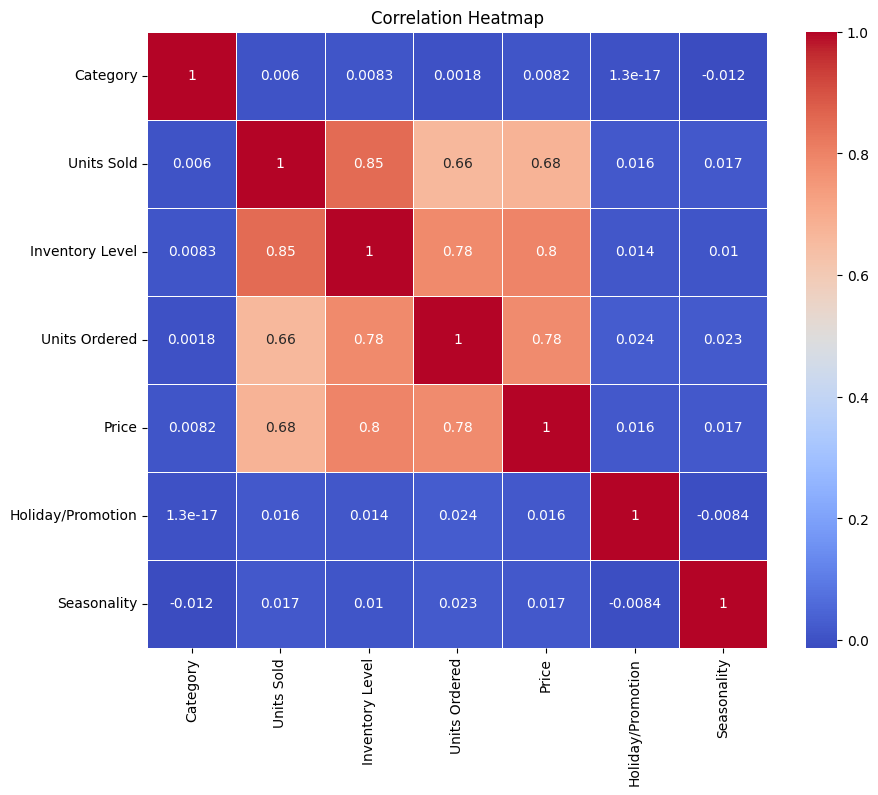

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Contoh: Heatmap korelasi antar fitur
plt.figure(figsize=(10, 8))
sns.heatmap(df_hasil.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

In [11]:
# Filter hanya untuk Kategori tertentu (misal: 0)
TARGET_CATEGORY = 0
df_cat0 = df_hasil[df_hasil['Category'] == TARGET_CATEGORY].copy()

# Buang kolom Category dan jadikan Date sebagai index
df_cat0 = df_cat0.drop(columns=['Category'])

print(f"Data Time Series Khusus Kategori {TARGET_CATEGORY}:")
display(df_cat0.head())

Data Time Series Khusus Kategori 0:


,Units Sold,Inventory Level,Units Ordered,Price,Holiday/Promotion,Seasonality
Date,,,,,,
2022-01-01,3784,6520,2200,1237.21,0,2
2022-01-02,2326,4163,2083,1010.79,0,1
2022-01-03,2524,5844,2494,1518.74,0,1
2022-01-04,2280,3877,1867,970.01,1,2
2022-01-05,1387,2650,944,584.57,0,1


In [12]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

feature_cols = ['Units Sold', 'Inventory Level', 'Units Ordered', 'Price', 'Holiday/Promotion', 'Seasonality']
data_array = df_cat0[feature_cols].values

# 1. Tentukan batas split data secara urut waktu (80% Train, 20% Test)
split_index = int(len(data_array) * 0.8)
train_data = data_array[:split_index]
test_data = data_array[split_index:]

# 2. Inisialisasi dan FIT Scaler HANYA PADA DATA TRAIN
scaler = MinMaxScaler()
train_data_scaled = scaler.fit_transform(train_data)

# 3. Transform data Test tanpa melakukan Fit (Mencegah mesin mengintip masa depan)
test_data_scaled = scaler.transform(test_data)

# 4. Gabungkan kembali untuk sementara guna dibuatkan Sliding Window
data_scaled = np.vstack((train_data_scaled, test_data_scaled))

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# 1. Pembuatan Sliding Window (30 hari)
def create_sequences(data, window_size=30):
    X, y = [], []
    target_indices = [0, 1] # Target: Units Sold dan Inventory Level
    for i in range(len(data) - window_size):
        X.append(data[i:(i + window_size), :])
        y.append(data[i + window_size, target_indices])
    return np.array(X), np.array(y)

WINDOW_SIZE = 30
X, y = create_sequences(data_scaled, WINDOW_SIZE)

# 2. Split X dan y berdasarkan urutan
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# 3. Pembuatan dan Training Model
model = Sequential()
model.add(LSTM(64, activation='relu', return_sequences=True, input_shape=(WINDOW_SIZE, len(feature_cols))))
model.add(Dropout(0.2))
model.add(LSTM(32, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(2))

model.compile(optimizer='adam', loss='mse')

print("Memulai training model LSTM bebas Data Leakage...")
history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_data=(X_test, y_test), verbose=2)

Memulai training model LSTM bebas Data Leakage...
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


35/35 - 8s - 215ms/step - loss: 0.0659 - val_loss: 0.0319
Epoch 2/50
35/35 - 2s - 54ms/step - loss: 0.0391 - val_loss: 0.0311
Epoch 3/50
35/35 - 1s - 34ms/step - loss: 0.0365 - val_loss: 0.0316
Epoch 4/50
35/35 - 1s - 22ms/step - loss: 0.0345 - val_loss: 0.0321
Epoch 5/50
35/35 - 1s - 20ms/step - loss: 0.0346 - val_loss: 0.0314
Epoch 6/50
35/35 - 1s - 37ms/step - loss: 0.0352 - val_loss: 0.0310
Epoch 7/50
35/35 - 1s - 20ms/step - loss: 0.0335 - val_loss: 0.0311
Epoch 8/50
35/35 - 1s - 21ms/step - loss: 0.0348 - val_loss: 0.0314
Epoch 9/50
35/35 - 1s - 21ms/step - loss: 0.0331 - val_loss: 0.0316
Epoch 10/50
35/35 - 1s - 21ms/step - loss: 0.0326 - val_loss: 0.0312
Epoch 11/50
35/35 - 1s - 21ms/step - loss: 0.0321 - val_loss: 0.0313
Epoch 12/50
35/35 - 1s - 24ms/step - loss: 0.0313 - val_loss: 0.0329
Epoch 13/50
35/35 - 1s - 32ms/step - loss: 0.0329 - val_loss: 0.0318
Epoch 14/50
35/35 - 1s - 38ms/step - loss: 0.0319 - val_loss: 0.0311
Epoch 15/50
35/35 - 1s - 24ms/step - loss: 0.0313 - v

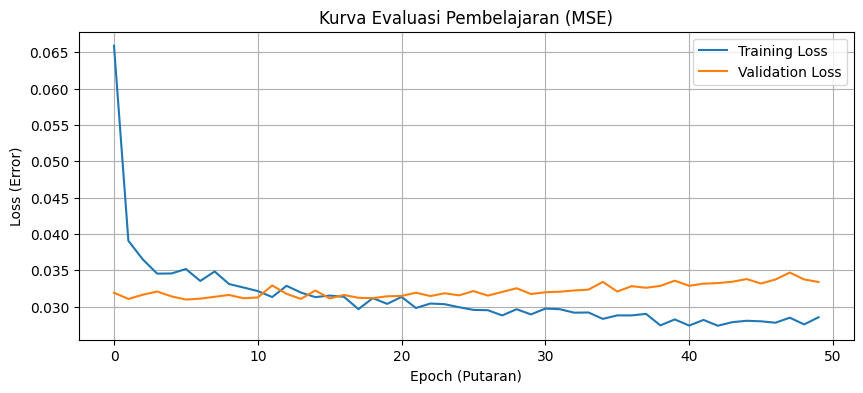

In [14]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Menampilkan grafik history training
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Kurva Evaluasi Pembelajaran (MSE)')
plt.xlabel('Epoch (Putaran)')
plt.ylabel('Loss (Error)')
plt.legend()
plt.grid(True)
plt.show()

In [15]:
print("Melakukan prediksi pada data Testing...")
y_pred_scaled = model.predict(X_test)

# Membuat "dummy array" agar fungsi inverse_transform bisa berjalan
# Pastikan variabel 'feature_cols' dan 'scaler' sudah terdefinisi saat training
dummy_pred = np.zeros((len(y_pred_scaled), len(feature_cols)))
dummy_pred[:, 0] = y_pred_scaled[:, 0] # Indeks 0: Units Sold
dummy_pred[:, 1] = y_pred_scaled[:, 1] # Indeks 1: Inventory Level

# Kembalikan tebakan ke nilai asli
y_pred_actual = scaler.inverse_transform(dummy_pred)[:, :2]

# Lakukan hal yang sama untuk data Test aslinya (Ground Truth)
dummy_test = np.zeros((len(y_test), len(feature_cols)))
dummy_test[:, 0] = y_test[:, 0]
dummy_test[:, 1] = y_test[:, 1]
y_test_actual = scaler.inverse_transform(dummy_test)[:, :2]

# Pastikan tidak ada tebakan bernilai minus (karena stok/penjualan minimal 0)
y_pred_actual = np.maximum(y_pred_actual, 0)

print("Proses Inverse Transform Berhasil!")

Melakukan prediksi pada data Testing...
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step
Proses Inverse Transform Berhasil!


In [16]:
# Hitung Error untuk target Units Sold (Indeks 0)
mae_units = mean_absolute_error(y_test_actual[:, 0], y_pred_actual[:, 0])
rmse_units = np.sqrt(mean_squared_error(y_test_actual[:, 0], y_pred_actual[:, 0]))

# Hitung Error untuk target Inventory Level (Indeks 1)
mae_inv = mean_absolute_error(y_test_actual[:, 1], y_pred_actual[:, 1])
rmse_inv = np.sqrt(mean_squared_error(y_test_actual[:, 1], y_pred_actual[:, 1]))

print("=== HASIL EVALUASI MODEL (SATUAN UNIT ASLI) ===")
print(f"[Units Sold]      Rata-rata Meleset (MAE): ± {mae_units:.2f} Unit | RMSE: {rmse_units:.2f} Unit")
print(f"[Inventory Level] Rata-rata Meleset (MAE): ± {mae_inv:.2f} Unit | RMSE: {rmse_inv:.2f} Unit")

=== HASIL EVALUASI MODEL (SATUAN UNIT ASLI) ===
[Units Sold]      Rata-rata Meleset (MAE): ± 618.17 Unit | RMSE: 771.51 Unit
[Inventory Level] Rata-rata Meleset (MAE): ± 1094.02 Unit | RMSE: 1356.84 Unit


In [17]:
from sklearn.metrics import mean_absolute_percentage_error

# Menghitung MAPE untuk target Units Sold (Indeks 0)
mape_units = mean_absolute_percentage_error(y_test_actual[:, 0], y_pred_actual[:, 0])

# Menghitung MAPE untuk target Inventory Level (Indeks 1)
mape_inv = mean_absolute_percentage_error(y_test_actual[:, 1], y_pred_actual[:, 1])

# Mengubahnya menjadi persentase (%) agar lebih mudah dibaca
print("=== HASIL EVALUASI PERSENTASE ERROR (MAPE) ===")
print(f"[Units Sold]      Tingkat Meleset (MAPE): {mape_units * 100:.2f}%")
print(f"[Inventory Level] Tingkat Meleset (MAPE): {mape_inv * 100:.2f}%")

=== HASIL EVALUASI PERSENTASE ERROR (MAPE) ===
[Units Sold]      Tingkat Meleset (MAPE): 25.73%
[Inventory Level] Tingkat Meleset (MAPE): 21.60%


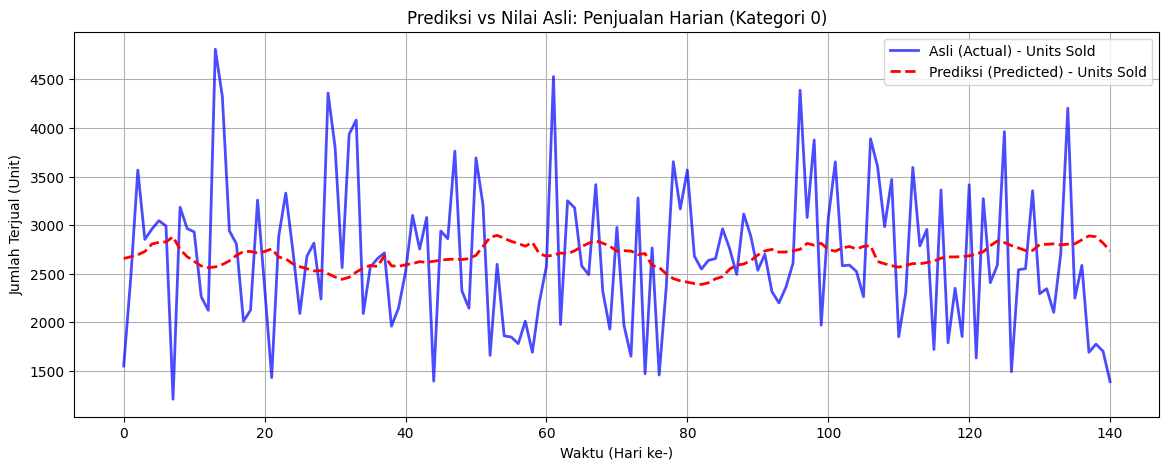

In [18]:
plt.figure(figsize=(14, 5))
plt.plot(y_test_actual[:, 0], label='Asli (Actual) - Units Sold', color='blue', alpha=0.7, linewidth=2)
plt.plot(y_pred_actual[:, 0], label='Prediksi (Predicted) - Units Sold', color='red', linestyle='dashed', linewidth=2)
plt.title(f'Prediksi vs Nilai Asli: Penjualan Harian (Kategori {TARGET_CATEGORY})')
plt.xlabel('Waktu (Hari ke-)')
plt.ylabel('Jumlah Terjual (Unit)')
plt.legend()
plt.grid(True)
plt.show()

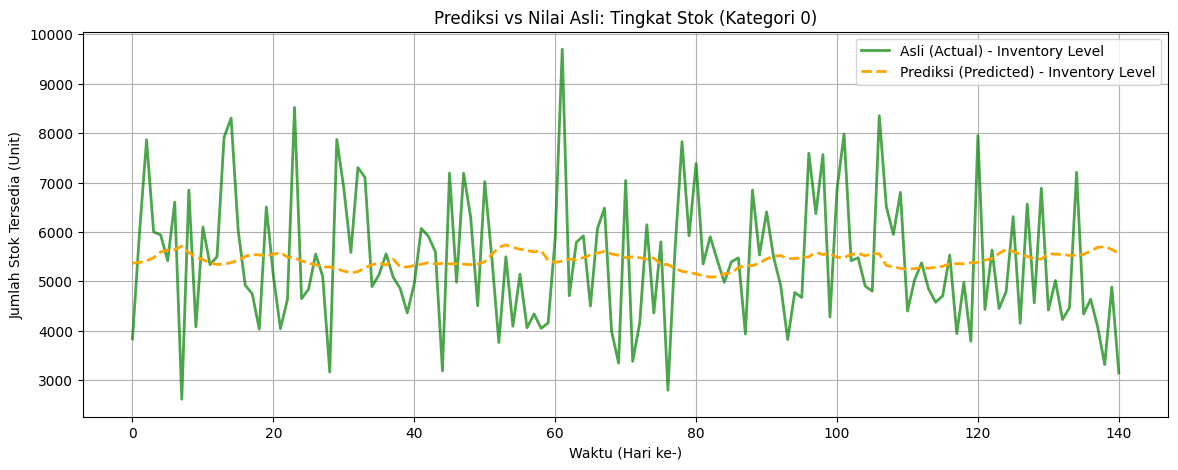

In [19]:
plt.figure(figsize=(14, 5))
plt.plot(y_test_actual[:, 1], label='Asli (Actual) - Inventory Level', color='green', alpha=0.7, linewidth=2)
plt.plot(y_pred_actual[:, 1], label='Prediksi (Predicted) - Inventory Level', color='orange', linestyle='dashed', linewidth=2)
plt.title(f'Prediksi vs Nilai Asli: Tingkat Stok (Kategori {TARGET_CATEGORY})')
plt.xlabel('Waktu (Hari ke-)')
plt.ylabel('Jumlah Stok Tersedia (Unit)')
plt.legend()
plt.grid(True)
plt.show()